### Clustring

In [1]:
from sklearn.cluster import KMeans, AgglomerativeClustering
import joblib
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import pandas as pd
import numpy as np

In [2]:
X_train = joblib.load("../data/processed/X_train.pkl")
X_test = joblib.load("../data/processed/X_test.pkl")


In [3]:
inertias = []
silhouette_scores = []
K_range = range(2, 10)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto")
    kmeans.fit(X_test)
    print(f"Number of clusters: {k}, Inertia: {kmeans.inertia_}, Silhouette Score: {silhouette_score(X_test, kmeans.labels_)}")
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_test, kmeans.labels_))

Number of clusters: 2, Inertia: 12295.168207889321, Silhouette Score: 0.21441426236372207
Number of clusters: 3, Inertia: 10861.52372280162, Silhouette Score: 0.1643466915344847
Number of clusters: 4, Inertia: 10228.972045554474, Silhouette Score: 0.13762317235415833
Number of clusters: 5, Inertia: 9533.099451979851, Silhouette Score: 0.139622169421093
Number of clusters: 6, Inertia: 9283.740058087722, Silhouette Score: 0.11696109510072704
Number of clusters: 7, Inertia: 8817.761348318683, Silhouette Score: 0.11828459619209995
Number of clusters: 8, Inertia: 8656.17898568045, Silhouette Score: 0.10939611604073911
Number of clusters: 9, Inertia: 8477.051530421024, Silhouette Score: 0.11156319902936349


In [4]:
k_range = range(2, 10)

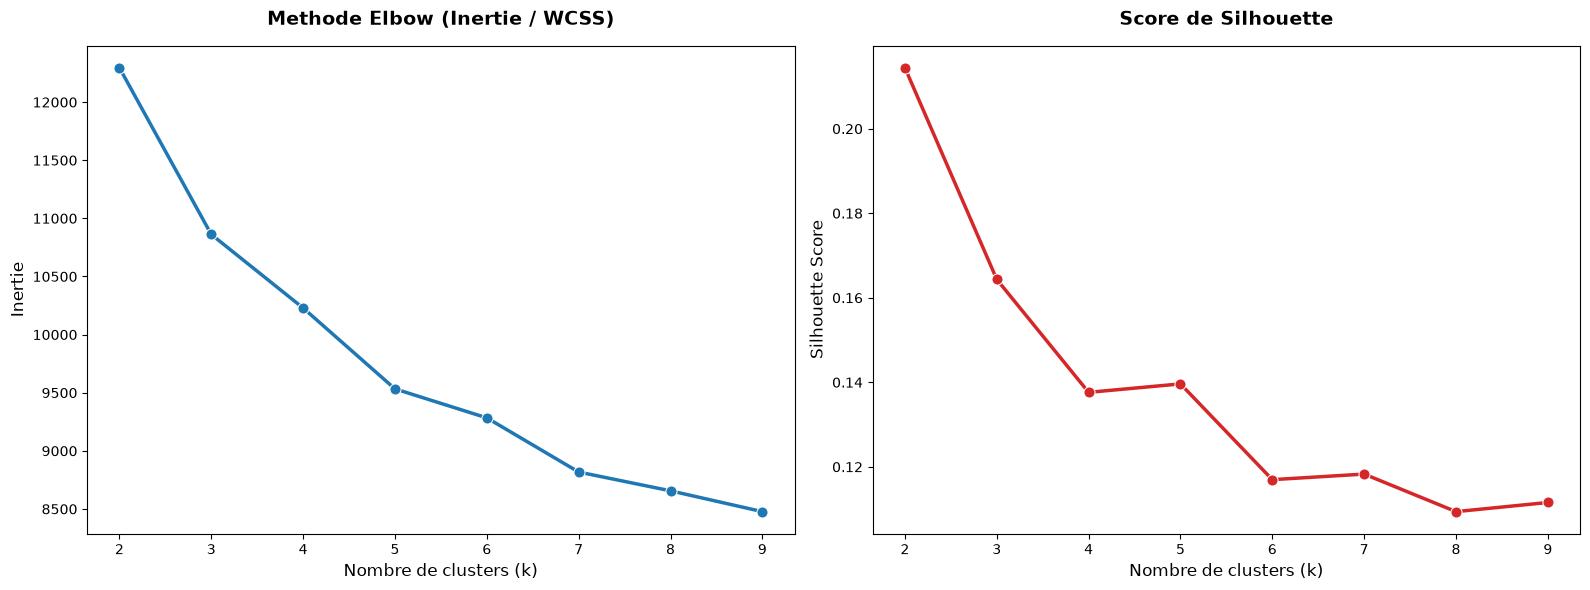

In [5]:
# 3. Creation de la figure a 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Graphique 1 : Methode Elbow ---
sns.lineplot(
    x=list(k_range), y=inertias, ax=axes[0], 
    marker='o', color='#1f77b4', linewidth=2.5, markersize=8
)
axes[0].set_title('Methode Elbow (Inertie / WCSS)', fontsize=14, fontweight='bold', pad=15)
axes[0].set_xlabel('Nombre de clusters (k)', fontsize=12)
axes[0].set_ylabel('Inertie', fontsize=12)
axes[0].set_xticks(list(k_range))

# --- Graphique 2 : Silhouette Score ---
sns.lineplot(
    x=list(k_range), y=silhouette_scores, ax=axes[1], 
    marker='o', color='#d62728', linewidth=2.5, markersize=8
)
axes[1].set_title('Score de Silhouette', fontsize=14, fontweight='bold', pad=15)
axes[1].set_xlabel('Nombre de clusters (k)', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_xticks(list(k_range))

plt.tight_layout()
plt.show()

In [6]:
k = 3


kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto")
kmeans.fit(X_train)

train_clusters = kmeans.predict(X_train)
test_clusters = kmeans.predict(X_test)

X_train_clustered = pd.DataFrame(X_train)
X_test_clustered = pd.DataFrame(X_test)

X_train_clustered["cluster"] = train_clusters
X_test_clustered["cluster"] = test_clusters


In [7]:
train_clusters_df = X_train_clustered.copy()

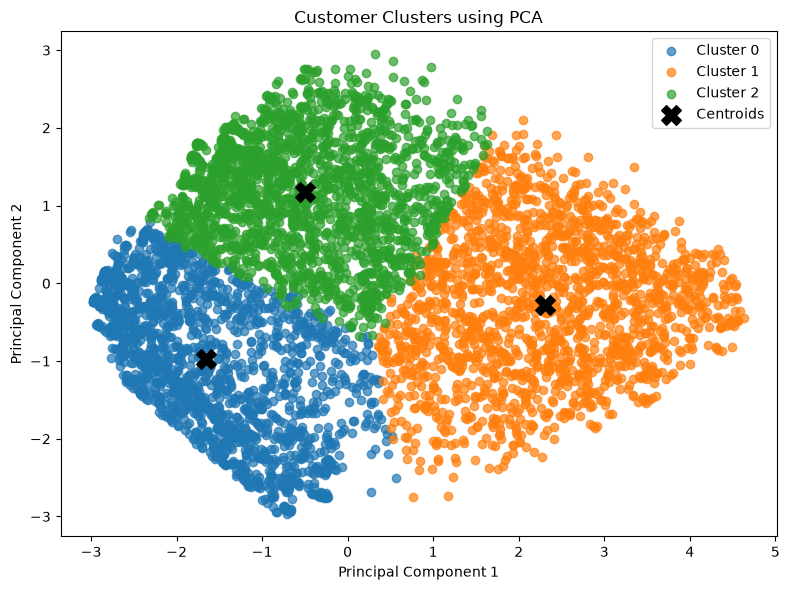

In [8]:

# PCA for 2D visualization
pca = PCA(n_components=2, random_state=42)
X_train_2d = pca.fit_transform(X_train)
centers_2d = pca.transform(kmeans.cluster_centers_)

# Plot clusters
plt.figure(figsize=(8, 6))
for cluster_id in range(k):
    idx = train_clusters_df['cluster'] == cluster_id
    plt.scatter(
        X_train_2d[idx, 0],
        X_train_2d[idx, 1],
        label=f"Cluster {cluster_id}",
        alpha=0.7
    )

plt.scatter(
    centers_2d[:, 0],
    centers_2d[:, 1],
    s=200,
    c="black",
    marker="X",
    label="Centroids"
)

plt.title("Customer Clusters using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.tight_layout()
plt.show()

In [9]:
X_train_final = pd.get_dummies(X_train_clustered, columns=['cluster'], prefix='cluster', dtype=int)
X_test_final = pd.get_dummies(X_test_clustered, columns=['cluster'], prefix='cluster', dtype=int)

joblib.dump(X_train_final, "../data/processed/X_train_with_cluster.pkl")
joblib.dump(X_test_final, "../data/processed/X_test_with_cluster.pkl")



['../data/processed/X_test_with_cluster.pkl']